In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import yfinance as yf
import sys
import random
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.ndimage import uniform_filter1d
from sklearn.preprocessing import MinMaxScaler

2026-03-19 21:42:26.916526: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773956547.107308      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773956547.170054      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773956547.679758      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773956547.679800      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773956547.679803      23 computation_placer.cc:177] computation placer alr

## Important Parameters and Tuning Setting

In [2]:
# Parameters
window_size = 5 # One month
batch_size = 32
shuffle_buffer_size = 0
# Turn on if you want to turn learning rate
tune_learning_rate = False

## Set Seed

In [3]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1' # Explicity Force Determinism on GPU
os.environ['PYTHONHASHSEED'] = '42' # Controls Hash Randomization

## Checking and Setting Device

In [4]:
# Selecting Cuda GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    os.environ["CUDA_VISIBLE_DEVICES"] = "0"
    # tf.debugging.set_log_device_placement(False) # TURN ON IF YOU WANT TO VERIFY THE GPU INFO
    print(f"Using GPU: {gpus[0].name}")
else:
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Disables GPU, forces CPU
    print("No CUDA GPU found — using CPU:", tf.config.list_physical_devices('CPU'))
    
# Confirm active device
print("Available devices:", tf.config.list_physical_devices())

Using GPU: /physical_device:GPU:0
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## User defined functions that will be used throughout the program

In [5]:
def plot_data(x, y, start=0, end=None, title=None, xlabel=None, 
              ylabel=None, legend=None, ax=None, alpha=1, axis='both'):
    
    # Logic: If no ax is provided, create a new one. 
    # If one is provided, use it (this is how subplots work).
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    if isinstance(y, tuple):    
        for y_curr in y:
            ax.plot(x[start:end], y_curr[start:end], "-", alpha = alpha)
    else:
        ax.plot(x[start:end], y[start:end], "-", alpha = alpha)

    # Note: axes objects use .set_title() and .set_xlabel() 
    # instead of plt.title() and plt.xlabel()
    ax.tick_params(axis=axis, which = 'major', labelsize=14)
    if title: ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if legend: ax.legend(legend)
    
    ax.grid(True)

def forecast_data(model, series, window_size, batch_size):
    # Generate a TF Dataset from the series values
    dataset = tf.data.Dataset.from_tensor_slices(series)

    # Window the data but only take those with the specified size
    dataset = dataset.window(window_size, shift=1, drop_remainder=True)

    # Flatten the windows by putting its elements in a single batch
    dataset = dataset.flat_map(lambda w: w.batch(window_size))
    
    # Create batches of windows
    dataset = dataset.batch(batch_size).prefetch(1)
    
    # Get predictions on the entire dataset
    forecast = model.predict(dataset, verbose=0)
    
    return forecast

## Input and Preprocessing

In [6]:
# Download data
df = yf.download("^GSPC", start="2005-01-01", interval="1d")
print(f"Successfully loaded {len(df)} days of S&P 500 data!")

# Raw data
closing_data = df['Close'].values
high_data    = df['High'].values
low_data     = df['Low'].values
vol_data     = df['Volume'].values
raw_prices   = df['Close'].values

# Define splits before scaling
n                = len(closing_data)
split_time_train = int(n * 0.75)
split_time_valid = int(n * 0.875)

print(f"Train:      {split_time_train}  ({split_time_train / n * 100:.1f}%)")
print(f"Validation: {split_time_valid - split_time_train}  ({(split_time_valid - split_time_train) / n * 100:.1f}%)")
print(f"Test:       {n - split_time_valid}  ({(n - split_time_valid) / n * 100:.1f}%)")

# Fit only on training data, transform all
close_scaler = MinMaxScaler()
high_scaler  = MinMaxScaler()
low_scaler   = MinMaxScaler()
vol_scaler   = MinMaxScaler()

close_MinMax = close_scaler.fit(closing_data[:split_time_train].reshape(-1, 1)).transform(closing_data.reshape(-1, 1))
high_MinMax  = high_scaler.fit(high_data[:split_time_train].reshape(-1, 1)).transform(high_data.reshape(-1, 1))
low_MinMax   = low_scaler.fit(low_data[:split_time_train].reshape(-1, 1)).transform(low_data.reshape(-1, 1))
vol_MinMax   = vol_scaler.fit(vol_data[:split_time_train].reshape(-1, 1)).transform(vol_data.reshape(-1, 1))

input_data        = np.column_stack([close_MinMax, high_MinMax, low_MinMax, vol_MinMax])
time_column       = np.arange(len(input_data))
time_column_dates = df.index.to_numpy()

print(f"Total data points: {len(input_data)}, Features: {input_data.shape[1]}")

/tmp/ipykernel_23/4270012384.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^GSPC", start="2005-01-01", interval="1d")
[*********************100%***********************]  1 of 1 completed

Successfully loaded 5336 days of S&P 500 data!
Train:      4002  (75.0%)
Validation: 667  (12.5%)
Test:       667  (12.5%)
Total data points: 5336, Features: 4


## Splits

In [7]:
# ── TRAINING SPLIT ────────────────────────────────────────────────────
time_train       = time_column[:split_time_train]
time_train_dates = time_column_dates[:split_time_train]
x_train          = input_data[:split_time_train]
close_MinMax_train  = input_data[:split_time_train, 0].flatten()
high_MinMax_train   = input_data[:split_time_train, 1].flatten()
low_MinMax_train    = input_data[:split_time_train, 2].flatten()
close_raw_train  = closing_data[:split_time_train].flatten()
high_raw_train   = high_data[:split_time_train].flatten()
low_raw_train    = low_data[:split_time_train].flatten()

# ── VALIDATION SPLIT ──────────────────────────────────────────────────
time_valid       = time_column[split_time_train:split_time_valid]
time_valid_dates = time_column_dates[split_time_train:split_time_valid]
x_valid          = input_data[split_time_train:split_time_valid]
close_MinMax_valid  = input_data[split_time_train:split_time_valid, 0].flatten()
high_MinMax_valid   = input_data[split_time_train:split_time_valid, 1].flatten()
low_MinMax_valid    = input_data[split_time_train:split_time_valid, 2].flatten()
close_raw_valid  = closing_data[split_time_train:split_time_valid].flatten()
high_raw_valid   = high_data[split_time_train:split_time_valid].flatten()
low_raw_valid    = low_data[split_time_train:split_time_valid].flatten()

# ── TEST SPLIT ────────────────────────────────────────────────────────
time_test       = time_column[split_time_valid:]
time_test_dates = time_column_dates[split_time_valid:]
x_test          = input_data[split_time_valid:]
close_MinMax_test  = input_data[split_time_valid:, 0].flatten()
high_MinMax_test   = input_data[split_time_valid:, 1].flatten()
low_MinMax_test    = input_data[split_time_valid:, 2].flatten()
close_raw_test  = closing_data[split_time_valid:].flatten()
high_raw_test   = high_data[split_time_valid:].flatten()
low_raw_test    = low_data[split_time_valid:].flatten()

## Graphing Data

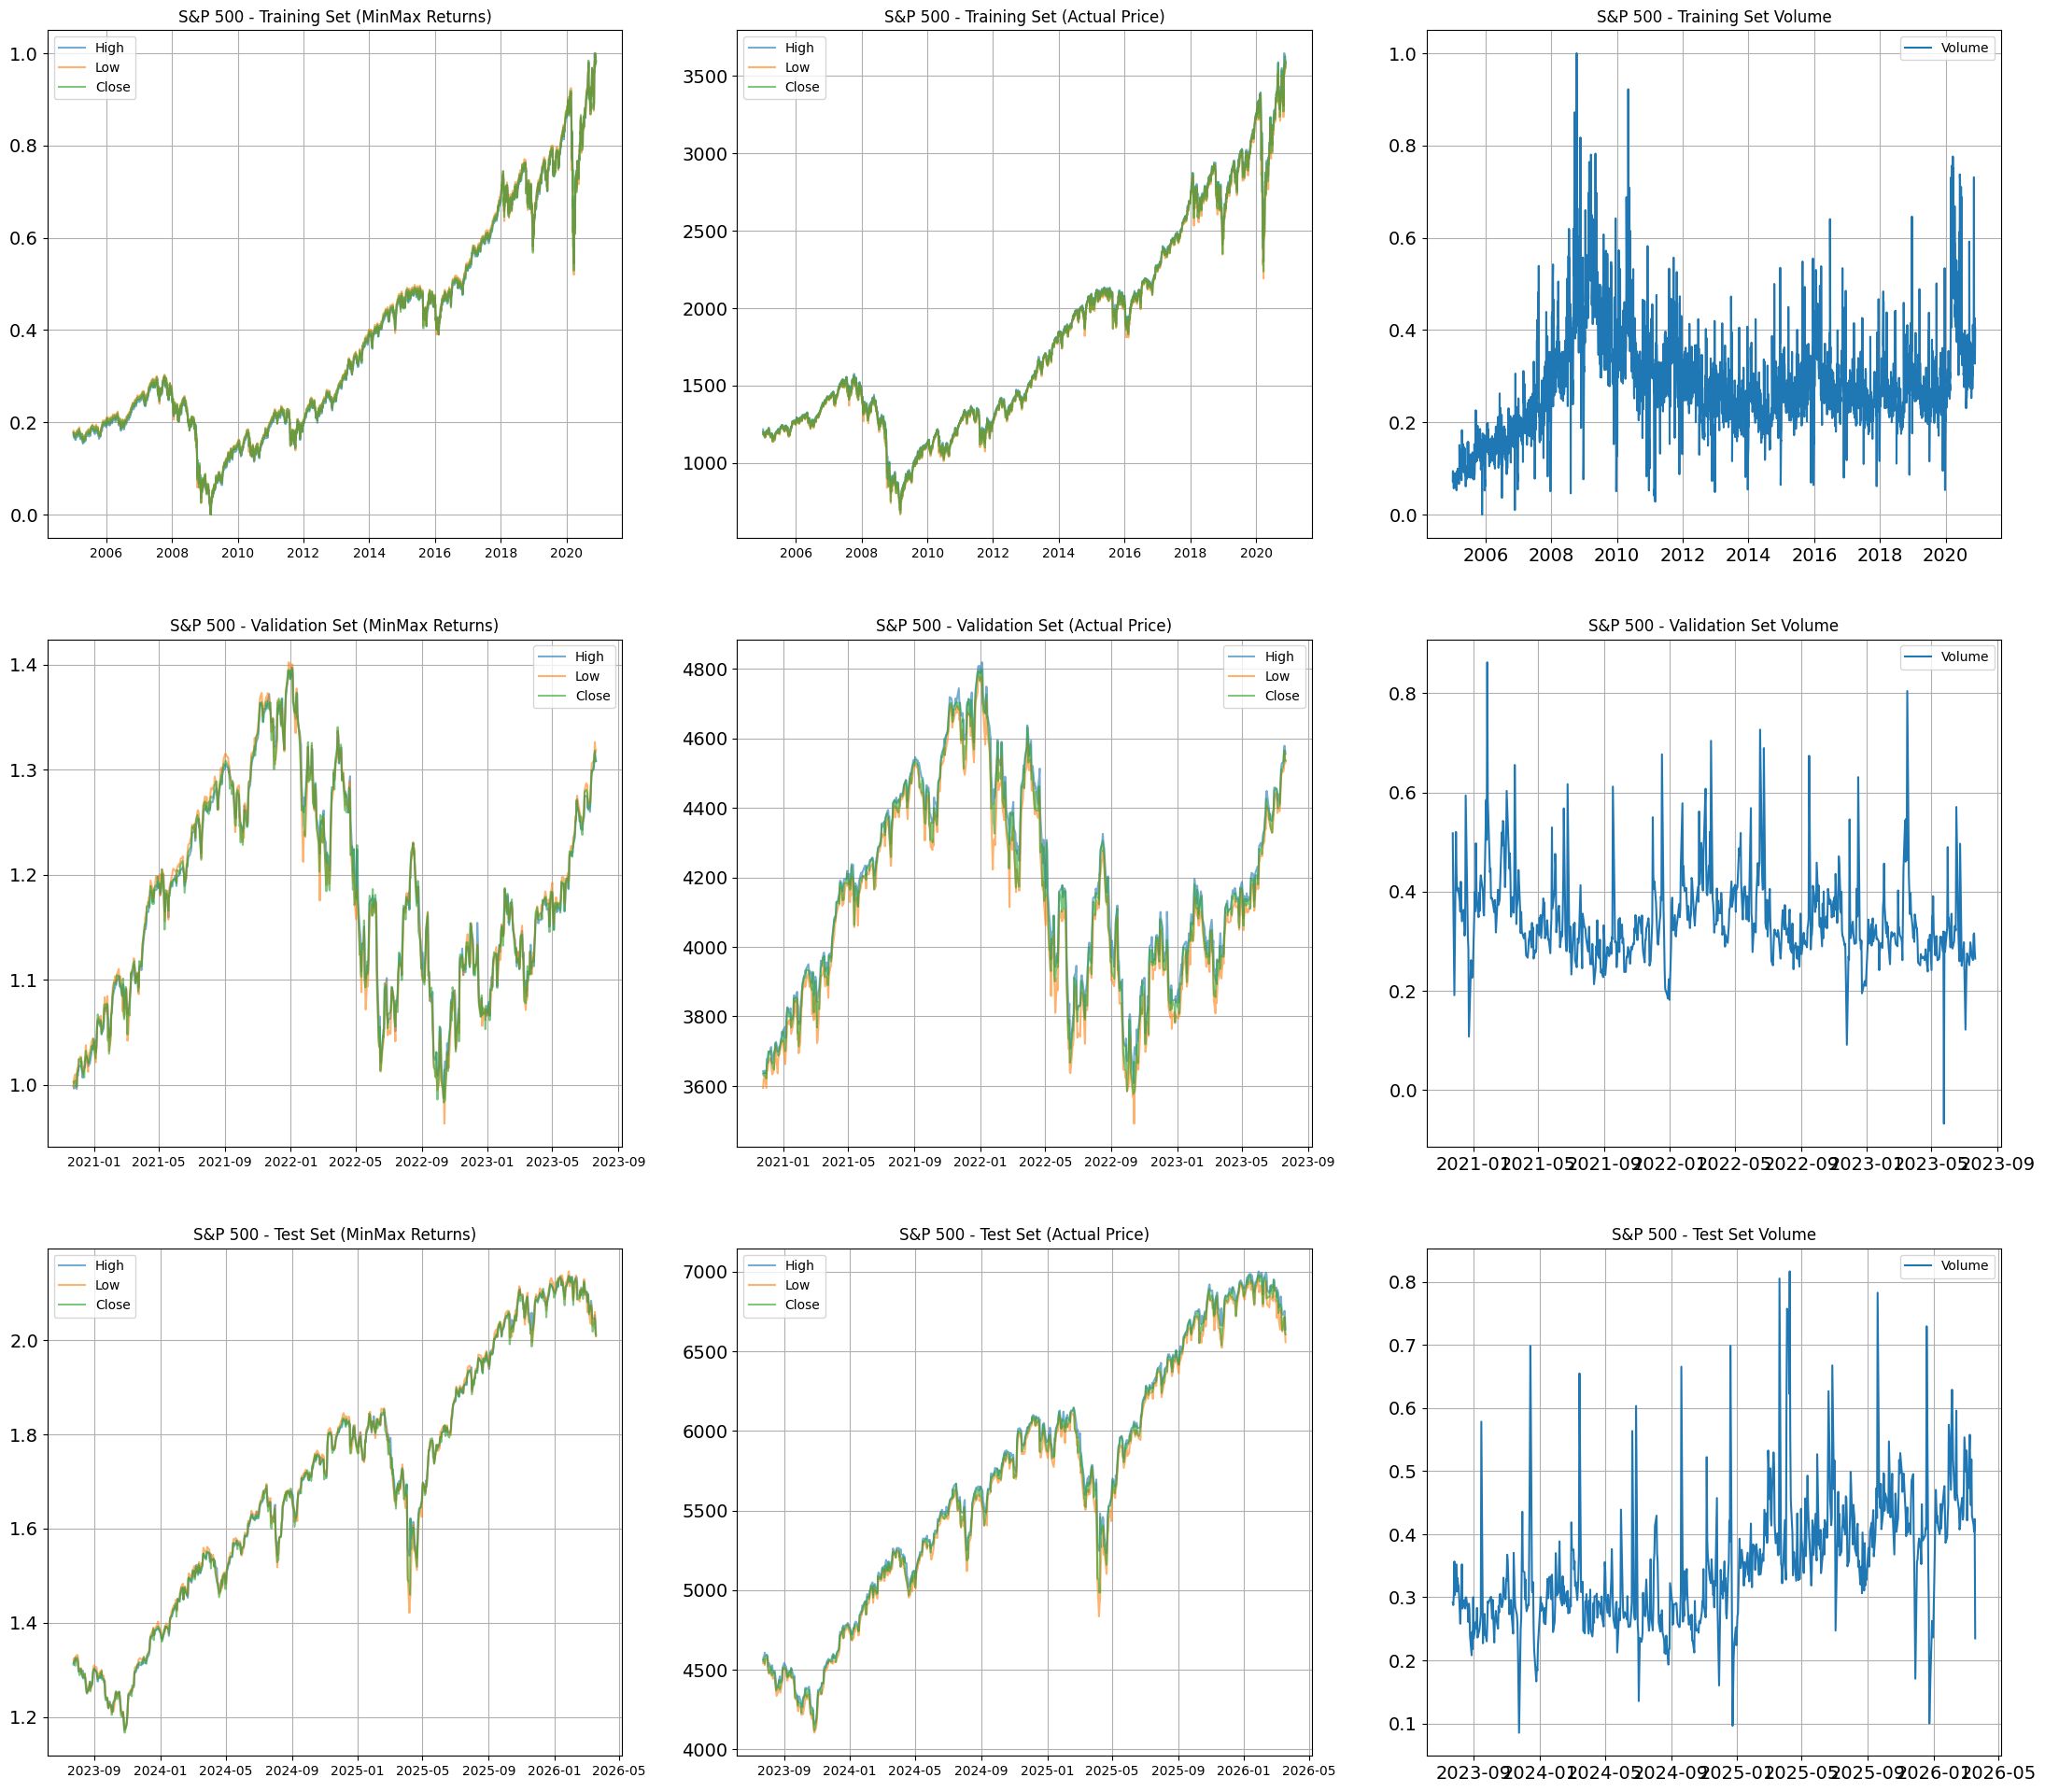

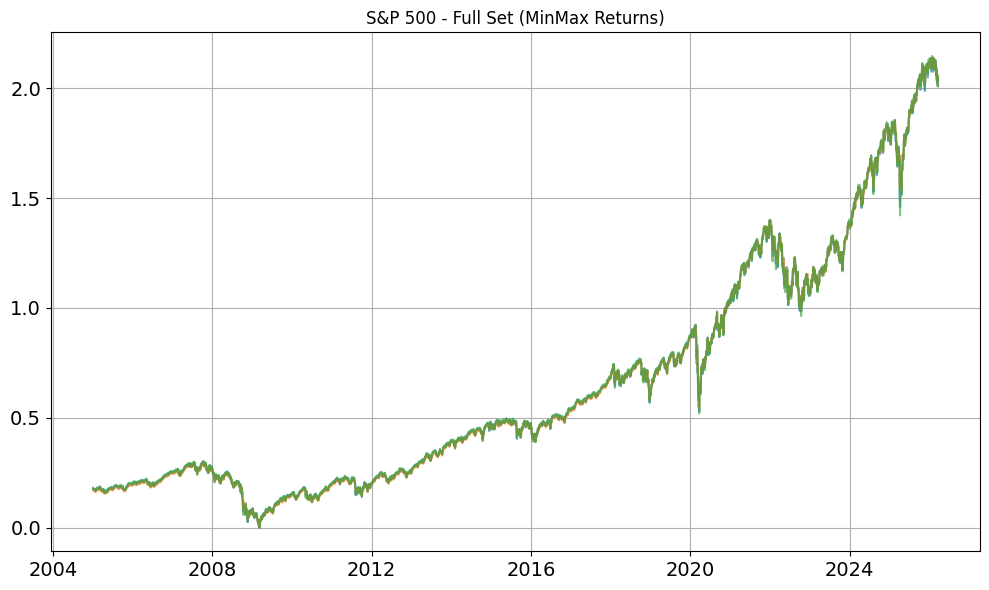

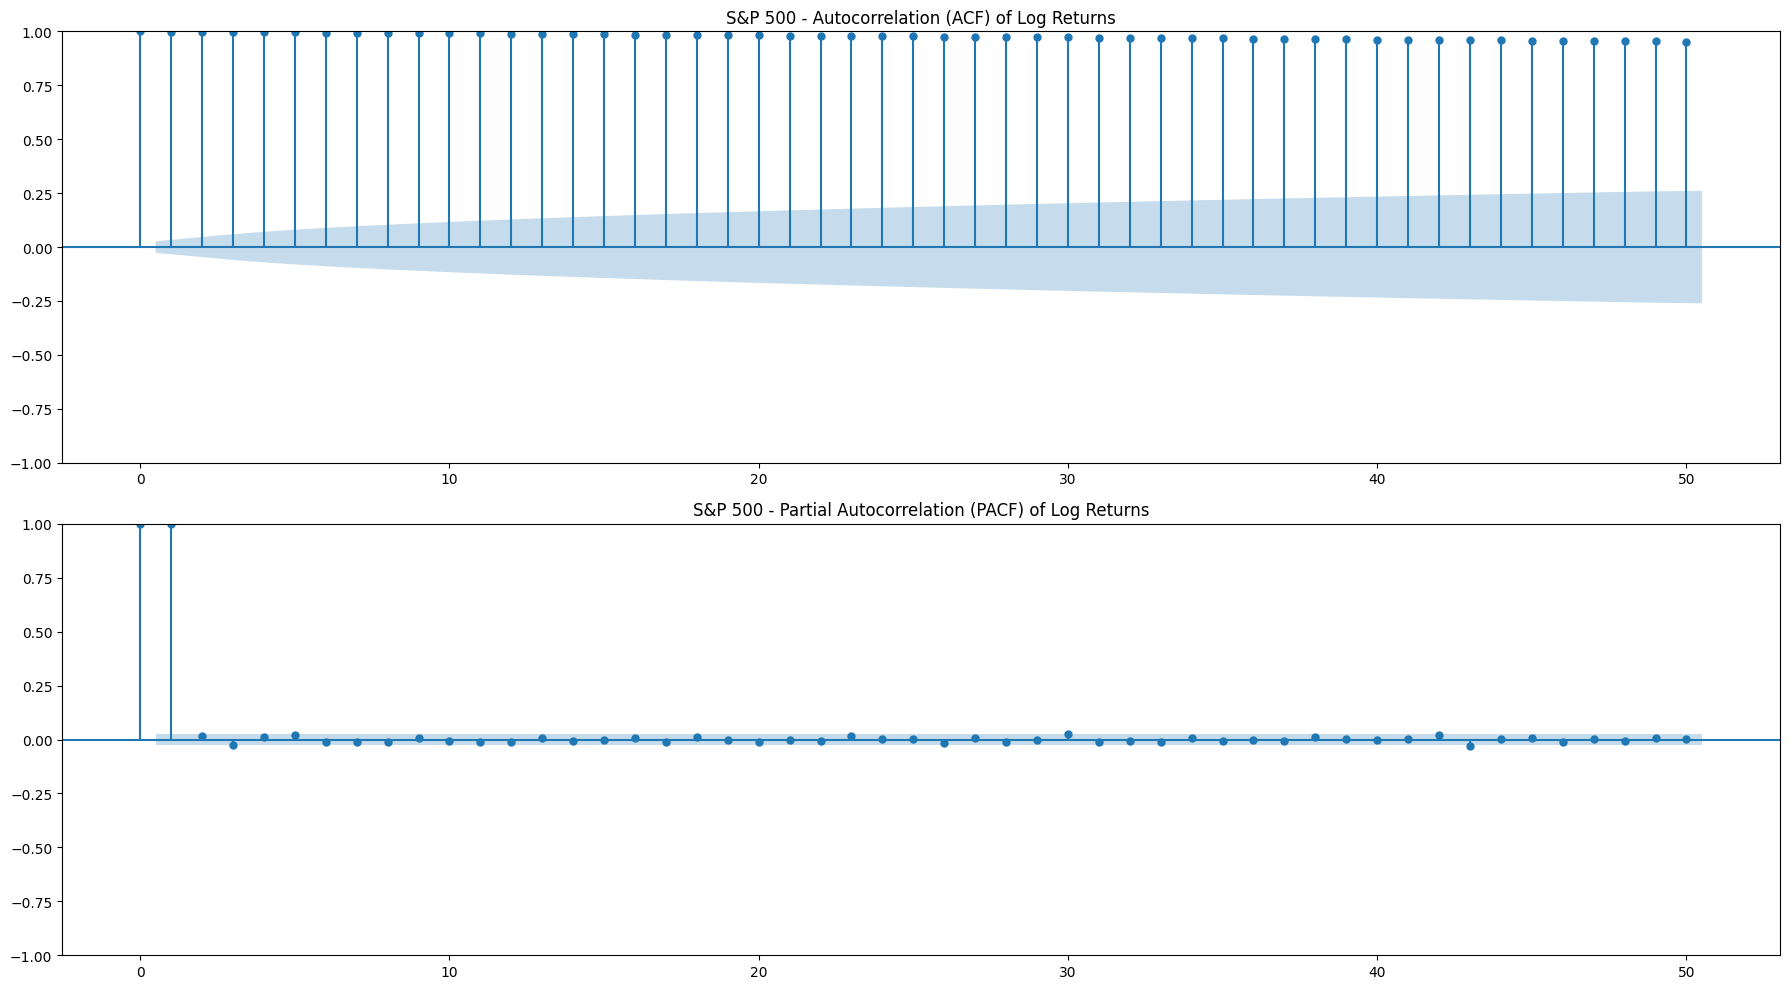

In [8]:
fig_data, axes_data = plt.subplots(3, 3, figsize=(27, 24))

# MinMax Transform
plot_data(time_train_dates, y=(high_MinMax_train, low_MinMax_train, close_MinMax_train),
          title="S&P 500 - Training Set (MinMax Returns)",   legend=["High", "Low", "Close"], ax=axes_data[0][0], alpha=0.6, axis = 'y')
plot_data(time_valid_dates, y=(high_MinMax_valid, low_MinMax_valid, close_MinMax_valid),
          title="S&P 500 - Validation Set (MinMax Returns)", legend=["High", "Low", "Close"], ax=axes_data[1][0], alpha=0.6, axis = 'y')
plot_data(time_test_dates,  y=(high_MinMax_test,  low_MinMax_test,  close_MinMax_test),
          title="S&P 500 - Test Set (MinMax Returns)",       legend=["High", "Low", "Close"], ax=axes_data[2][0], alpha=0.6, axis = 'y')

# Actual Prices
plot_data(time_train_dates, y=(high_raw_train, low_raw_train, close_raw_train),
          title="S&P 500 - Training Set (Actual Price)",   legend=["High", "Low", "Close"], ax=axes_data[0][1], alpha=0.6, axis = 'y')
plot_data(time_valid_dates, y=(high_raw_valid, low_raw_valid, close_raw_valid),
          title="S&P 500 - Validation Set (Actual Price)", legend=["High", "Low", "Close"], ax=axes_data[1][1], alpha=0.6, axis = 'y')
plot_data(time_test_dates,  y=(high_raw_test,  low_raw_test,  close_raw_test),
          title="S&P 500 - Test Set (Actual Price)",       legend=["High", "Low", "Close"], ax=axes_data[2][1], alpha=0.6, axis = 'y')

# Volume Split
plot_data(time_train_dates, input_data[:split_time_train, 3].flatten(),
          title="S&P 500 - Training Set Volume",   legend=["Volume"], ax=axes_data[0][2])
plot_data(time_valid_dates, input_data[split_time_train:split_time_valid, 3].flatten(),
          title="S&P 500 - Validation Set Volume", legend=["Volume"], ax=axes_data[1][2])
plot_data(time_test_dates,  input_data[split_time_valid:, 3].flatten(),
          title="S&P 500 - Test Set Volume",       legend=["Volume"], ax=axes_data[2][2])

# Full Graph
vertical_axis_close = np.concatenate((close_MinMax_train, close_MinMax_valid, close_MinMax_test))
vertical_axis_high  = np.concatenate((high_MinMax_train, high_MinMax_valid, high_MinMax_test))
vertical_axis_low   = np.concatenate((low_MinMax_train, low_MinMax_valid, low_MinMax_test))

plot_data(time_column_dates, y=(vertical_axis_close,vertical_axis_high,vertical_axis_low),
         title="S&P 500 - Full Set (MinMax Returns)", alpha=0.6)

plt.tight_layout()
plt.show()

# ACF / PACF
fig_acf, axes_ACF_PACF = plt.subplots(2, 1, figsize=(18, 10))
ax_acf  = axes_ACF_PACF[0]
ax_pacf = axes_ACF_PACF[1]
max_lags = 50

plot_acf(input_data[:, 0].squeeze(), lags=max_lags, ax=ax_acf,
         title="S&P 500 - Autocorrelation (ACF) of Log Returns")
plot_pacf(input_data[:, 0].squeeze(), lags=max_lags, ax=ax_pacf,
          title="S&P 500 - Partial Autocorrelation (PACF) of Log Returns", method='ywm')

plt.tight_layout()
plt.show()

## Getting Labels from Data

In [9]:
# Function for creating the actual X and Y (labels and data)
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    # series is already (T, n_features) — no expand_dims needed
    dataset = tf.data.Dataset.from_tensor_slices(series)

    # Window: grab window_size+1 rows at a time
    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))

    # X = all features for first window_size steps, y = close return of last step
    dataset = dataset.map(lambda window: (window[:-1], window[-1, 0]))

    if shuffle_buffer:
        dataset = dataset.shuffle(shuffle_buffer)

    dataset = dataset.batch(batch_size).cache().prefetch(1)
    return dataset

# Create Windowed Dataset
train_dataset = windowed_dataset(x_train, window_size, batch_size, 0)
valid_dataset = windowed_dataset(x_valid, window_size, batch_size, 0)
test_dataset  = windowed_dataset(x_test,  window_size, batch_size, 0)

I0000 00:00:1773956578.295025      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773956578.297809      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Model Architecture

In [10]:
n_features = input_data.shape[1]  # amount of data columnss
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(window_size, n_features)),
    tf.keras.layers.Conv1D(filters=64, kernel_size=5, padding="causal", activation="relu"),
    tf.keras.layers.LSTM(128, return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(0.0005)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(64),
    #tf.keras.layers.LSTM(32),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5, 64)          │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 5, 128)         │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,681 (592.50 KB)

 Trainable params: 151,681 (592.50 KB)

 Non-trainable params: 0 (0.00 B)

## Tuning The Model

In [11]:
if tune_learning_rate is True:
    # Save and reset weights before sweep
    init_weights = model.get_weights()
    model.set_weights(init_weights)

    # Sweep from 1e-6 to 1e-1 over 100 epochs
    lr_schedule = tf.keras.callbacks.LearningRateScheduler(
        lambda epoch: 1e-6 * 10**(epoch / 20))

    model.compile(
        loss='mse',
        optimizer=tf.keras.optimizers.Adam()
    )

    history = model.fit(
        train_dataset,
        epochs=100,
        callbacks=[lr_schedule],
        verbose=0
    )

    # Restore weights after sweep so model is clean for real training
    model.set_weights(init_weights)

    # Match LR array to schedule
    lrs = 1e-6 * (10 ** (np.arange(100) / 20))

    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.semilogx(lrs, history.history["loss"])
    ax.axvline(x=1e-5, color='purple', linestyle='--', label='1e-5')
    ax.axvline(x=1e-4, color='g',      linestyle='--', label='1e-4')
    ax.axvline(x=1e-3, color='b',      linestyle='--', label='1e-3')
    ax.axvline(x=1e-2, color='r',      linestyle='--', label='1e-2')
    ax.set_title('Learning Rate Finder')
    ax.set_xlabel('Learning Rate (log scale)')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    sys.exit(0)

## Train Model

In [12]:
# Get initial weights
init_weights = model.get_weights()
#Learning Rate set
learning_rate = 0.7e-4
# Reset the weights
model.set_weights(init_weights)
# Set the optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# Set the training parameters
model.compile(loss='mse',#tf.keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"]
             )

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(train_dataset,
                    epochs=200,
                    validation_data=valid_dataset,
                    verbose=2,
                    callbacks=[early_stopping])

Epoch 1/200


I0000 00:00:1773956582.456621      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


125/125 - 6s - 44ms/step - loss: 0.0725 - mae: 0.1283 - val_loss: 0.0704 - val_mae: 0.1473
Epoch 2/200
125/125 - 1s - 7ms/step - loss: 0.0510 - mae: 0.0817 - val_loss: 0.0532 - val_mae: 0.1174
Epoch 3/200
125/125 - 1s - 7ms/step - loss: 0.0408 - mae: 0.0705 - val_loss: 0.0442 - val_mae: 0.1098
Epoch 4/200
125/125 - 1s - 7ms/step - loss: 0.0330 - mae: 0.0615 - val_loss: 0.0324 - val_mae: 0.0796
Epoch 5/200
125/125 - 1s - 7ms/step - loss: 0.0264 - mae: 0.0516 - val_loss: 0.0258 - val_mae: 0.0667
Epoch 6/200
125/125 - 1s - 7ms/step - loss: 0.0216 - mae: 0.0444 - val_loss: 0.0211 - val_mae: 0.0588
Epoch 7/200
125/125 - 1s - 7ms/step - loss: 0.0178 - mae: 0.0390 - val_loss: 0.0191 - val_mae: 0.0658
Epoch 8/200
125/125 - 1s - 7ms/step - loss: 0.0147 - mae: 0.0338 - val_loss: 0.0160 - val_mae: 0.0596
Epoch 9/200
125/125 - 1s - 7ms/step - loss: 0.0124 - mae: 0.0308 - val_loss: 0.0126 - val_mae: 0.0467
Epoch 10/200
125/125 - 1s - 7ms/step - loss: 0.0107 - mae: 0.0286 - val_loss: 0.0119 - val_ma

## Plot MAE and Loss

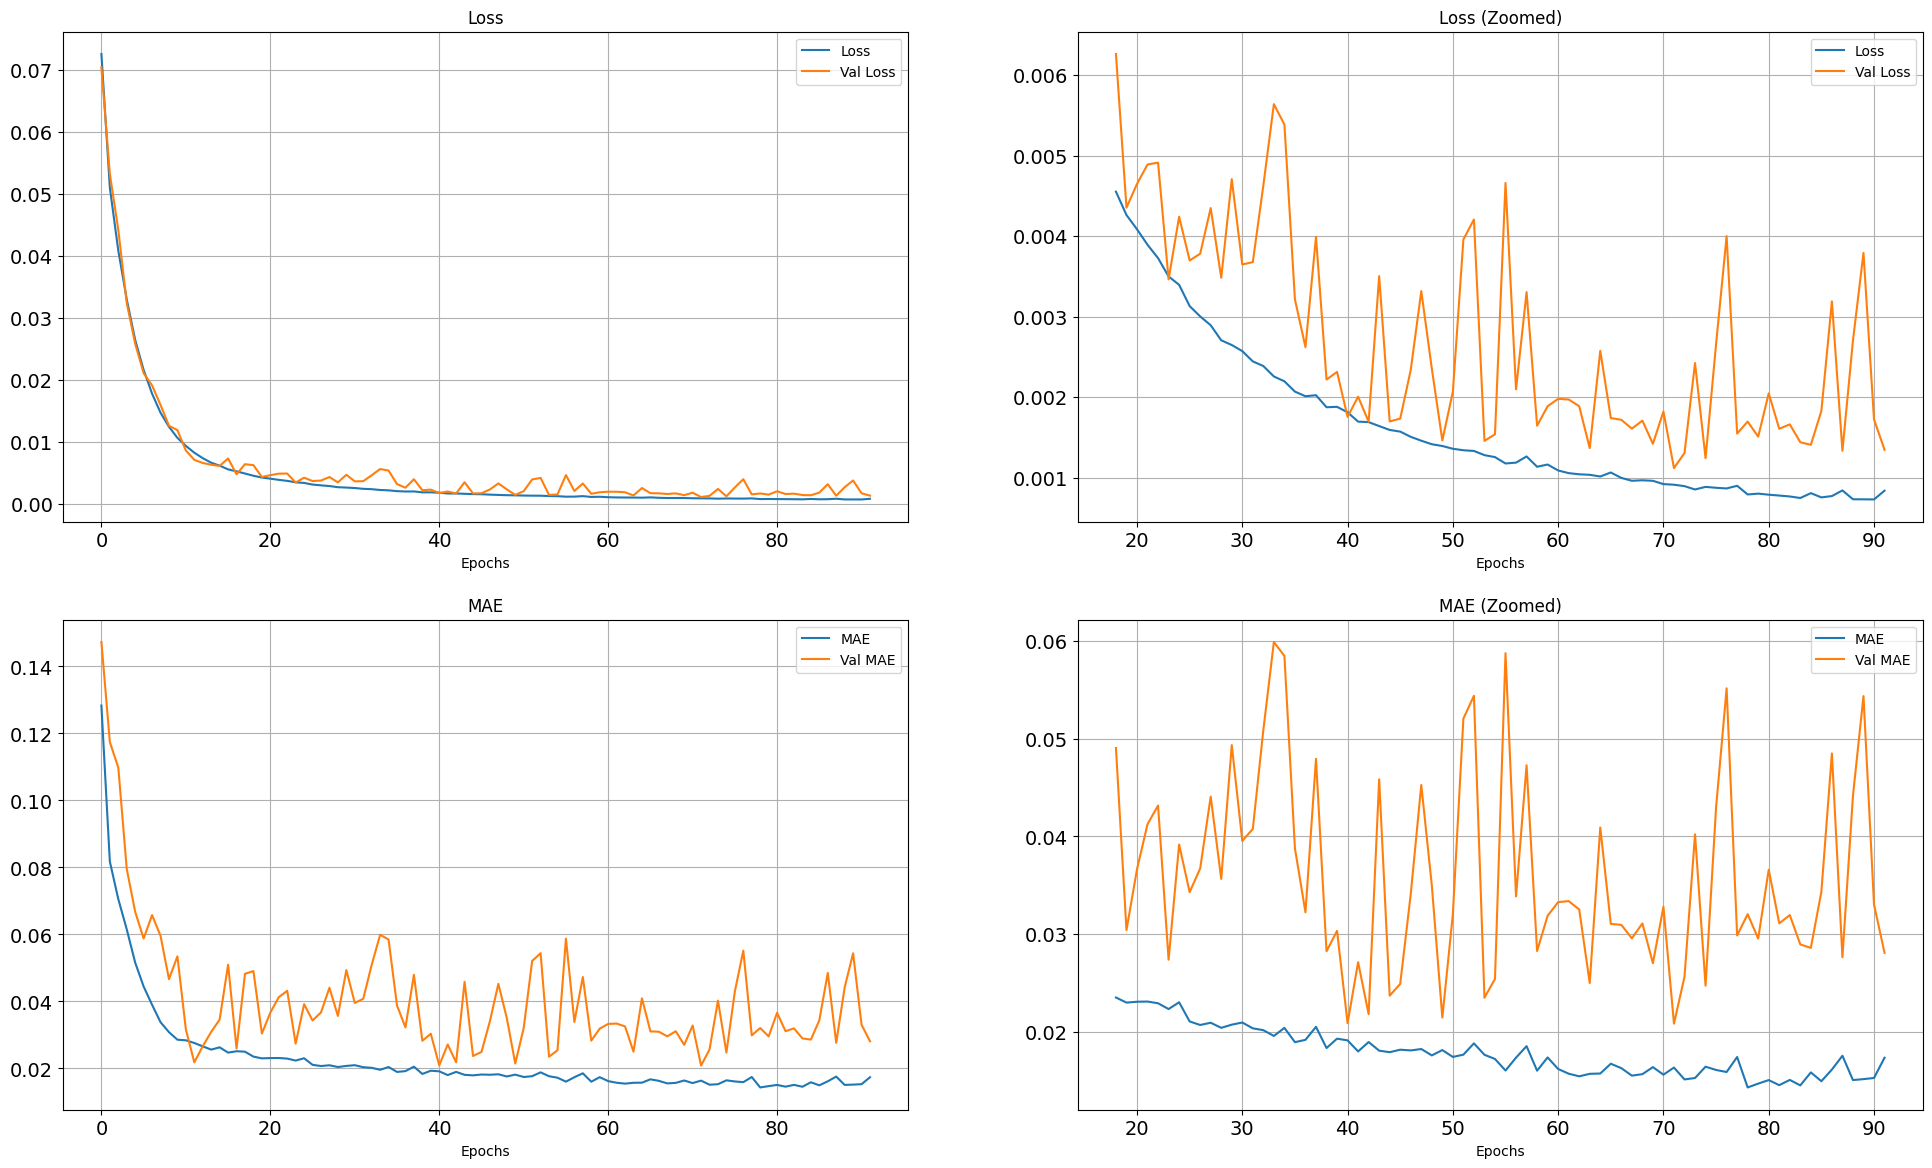

In [13]:
# Get mae and loss from history log
mae      = history.history['mae']
loss     = history.history['loss']
val_mae  = history.history['val_mae']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(len(loss))

# Plot mae and loss

fig_loss, axes_loss_MAE = plt.subplots(2, 2, figsize=(24, 14))

#Plot Loss
plot_data(
    x=epochs,
    y=(loss, val_loss),
    title='Loss',
    xlabel='Epochs',
    legend=['Loss', 'Val Loss'],
    ax=axes_loss_MAE[0][0]
)

#Plot MAE
plot_data(
    x=epochs,
    y=(mae, val_mae),
    title='MAE',
    xlabel='Epochs',
    legend=['MAE', 'Val MAE'],
    ax=axes_loss_MAE[1][0]
)

# Only plot the last 80% of the epochs
zoom_split = int(epochs[-1] * 0.2)
epochs_zoom   = epochs[zoom_split:]
mae_zoom      = mae[zoom_split:]
loss_zoom     = loss[zoom_split:]
val_mae_zoom  = val_mae[zoom_split:]
val_loss_zoom = val_loss[zoom_split:]

# Plot zoomed Loss
plot_data(
    x=epochs_zoom,
    y=(loss_zoom, val_loss_zoom),
    title='Loss (Zoomed)',
    xlabel='Epochs',
    legend=['Loss', 'Val Loss'],
    ax=axes_loss_MAE[0][1]
)

# Plot zoomed MAE
plot_data(
    x=epochs_zoom,
    y=(mae_zoom, val_mae_zoom),
    title='MAE (Zoomed)',
    xlabel='Epochs',
    legend=['MAE', 'Val MAE'],
    ax=axes_loss_MAE[1][1]
)


## Info for Debugging

In [14]:
print(f"input_data shape:  {input_data.shape}")
print(f"raw_prices shape:    {raw_prices.shape}")
print(f"split_time_train:    {split_time_train}")
print(f"split_time_valid:    {split_time_valid}")
print(f"len(time_train):     {len(time_train)}")
print(f"len(time_valid):     {len(time_valid)}")
print(f"len(time_test):      {len(time_test)}")
print(f"window_size:         {window_size}")

input_data shape:  (5336, 4)
raw_prices shape:    (5336, 1)
split_time_train:    4002
split_time_valid:    4669
len(time_train):     4002
len(time_valid):     667
len(time_test):      667
window_size:         5


## Forecasting

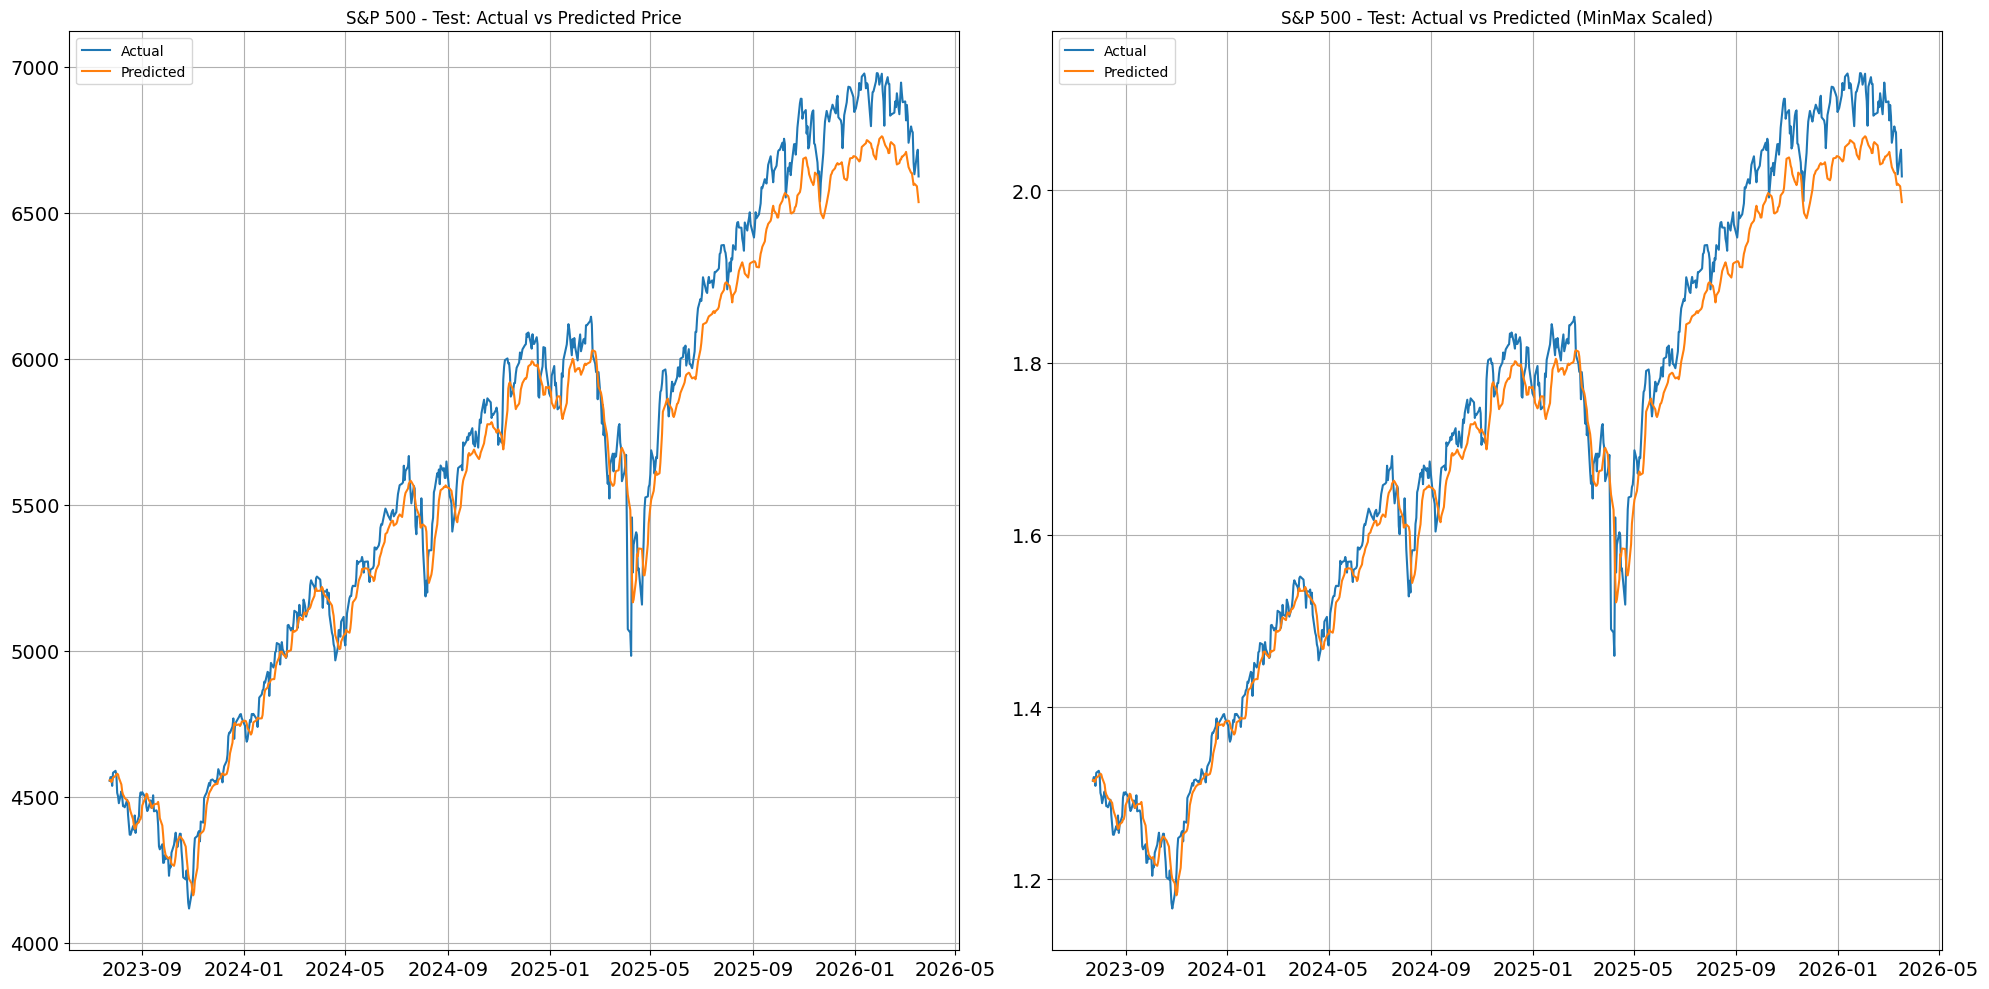

In [15]:
forecast_series = input_data[split_time_valid - window_size:]
forecast        = forecast_data(model, forecast_series, window_size, batch_size)
results         = forecast.squeeze()

n = len(time_test)

# Trim trailing NaN produced by forecast windowing 
predicted_minmax = results[-n:-1]
n                = len(predicted_minmax)

time_test_trimmed_dates = time_test_dates[:n]

# Scaled original (matched length)
actual_minmax = input_data[split_time_valid : split_time_valid + n, 0].flatten()

# Inverse MinMax price space
results_test_prices = close_scaler.inverse_transform(predicted_minmax.reshape(-1, 1)).flatten()
actual_test_prices  = close_scaler.inverse_transform(actual_minmax.reshape(-1, 1)).flatten()

fig_results, axes_results = plt.subplots(1, 2, figsize=(20, 10))

plot_data(time_test_trimmed_dates, (actual_test_prices, results_test_prices),
          title="S&P 500 - Test: Actual vs Predicted Price",
          legend=["Actual", "Predicted"], ax=axes_results[0])

plot_data(time_test_trimmed_dates, (actual_minmax, predicted_minmax),
          title="S&P 500 - Test: Actual vs Predicted (MinMax Scaled)",
          legend=["Actual", "Predicted"], ax=axes_results[1])

plt.tight_layout()
plt.show()

## Metrics

In [16]:
rmse_test = np.sqrt(np.mean((actual_test_prices - results_test_prices) ** 2))
mae_test  = np.mean(np.abs(actual_test_prices - results_test_prices))
mape_test = np.mean(np.abs((actual_test_prices - results_test_prices) / actual_test_prices)) * 100

print(f"Model Test RMSE:  {rmse_test:.3f}")
print(f"Model Test MAE:   {mae_test:.3f}")
print(f"Model Test MAPE:  {mape_test:.3f}%")


Model Test RMSE:  122.042
Model Test MAE:   97.699
Model Test MAPE:  1.646%


## Month Prediction

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


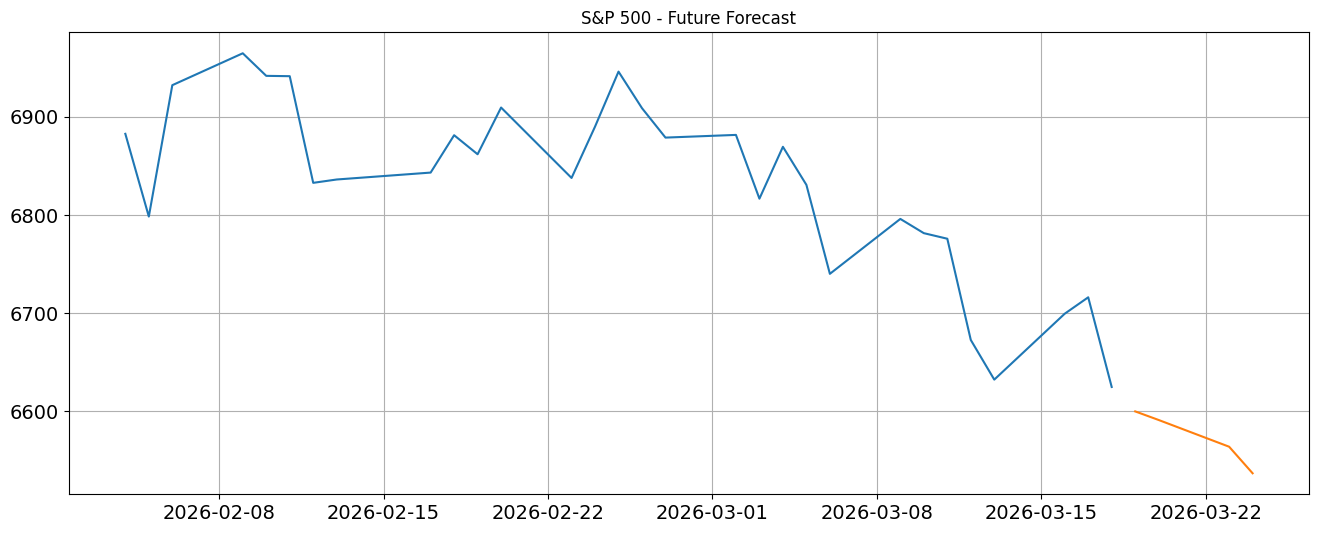

In [17]:
 # Future Forecast

forecast_future  = forecast_data(model, input_data[-(window_size * 2):], window_size, batch_size)
predicted_future = forecast_future.squeeze()[-window_size:-1]  # trim trailing NaN

# Inverse MinMax price space
results_future_prices = close_scaler.inverse_transform(
    predicted_future.reshape(-1, 1)
).flatten()

# Context window: last 100 actual prices
context_dates  = time_test_trimmed_dates[-30:]
context_prices = actual_test_prices[-30:]

future_dates = pd.date_range(
    start=time_test_trimmed_dates[-1], periods=window_size + 1, freq="B"
)[1:]

# Trim future_dates to match in case of NaN trimming above
future_dates = future_dates[:len(results_future_prices)]

# Plot
fig_future, ax_future = plt.subplots(figsize=(16, 6))
plot_data(context_dates,  context_prices,        title="S&P 500 - Future Forecast", ax=ax_future)
plot_data(future_dates,   results_future_prices,                          ax=ax_future)
plt.show()